Multi-Asset ETF Portfolio Strategy Analysis

This project analyzes the performance of a diversified portfolio of exchange-traded funds (ETFs) representing major asset classes such as equities, bonds, commodities, and real assets. 

The goal of the analysis is to understand how different portfolio allocation strategies affect risk and return over time.

Using historical market data from Yahoo Finance, the project will:

- Collect historical price data for several ETFs
- Calculate daily returns
- Construct multiple portfolio strategies
- Compare portfolio performance using risk and return metrics
- Visualize portfolio behavior over time

The ETFs selected represent different segments of global financial markets, allowing us to study diversification across asset classes.

Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

Step 2 — Define ETF Universe

In [5]:
tickers = ["SPY", "QQQ", "VTI", "EFA", "VNQ", "TLT"]

In [8]:
data = yf.download(tickers, start="2018-01-01")
data = data["Close"]
data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,EFA,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,
2018-01-02,55.603325,150.411591,237.208282,99.857224,60.814205,121.840889
2018-01-03,55.870216,151.873062,238.708572,100.334656,60.637665,122.546089
2018-01-04,56.482544,152.138809,239.714722,100.318756,59.593071,123.013329
2018-01-05,56.796555,153.666733,241.312180,100.032310,59.622494,123.736115
2018-01-08,56.780861,154.264587,241.753479,99.968620,59.931461,124.018204


Step 3 — Calculate Daily Returns

To analyze portfolio performance, we convert price data into daily percentage returns.  
Returns measure how much each asset changes in value from one trading day to the next.

In [9]:
returns = data.pct_change().dropna()
returns.head()

Ticker,EFA,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,
2018-01-03,0.004800,0.009716,0.006325,0.004781,-0.002903,0.005788
2018-01-04,0.010960,0.001750,0.004215,-0.000158,-0.017227,0.003813
2018-01-05,0.005559,0.010043,0.006664,-0.002855,0.000494,0.005876
2018-01-08,-0.000276,0.003891,0.001829,-0.000637,0.005182,0.002280
2018-01-09,0.001106,0.000062,0.002263,-0.013373,-0.012888,0.001848


Step 4 — Growth of $1 Invested

To understand how each ETF performed over time, we calculate cumulative returns.
This simulates how $1 invested in each asset would grow over the sample period.

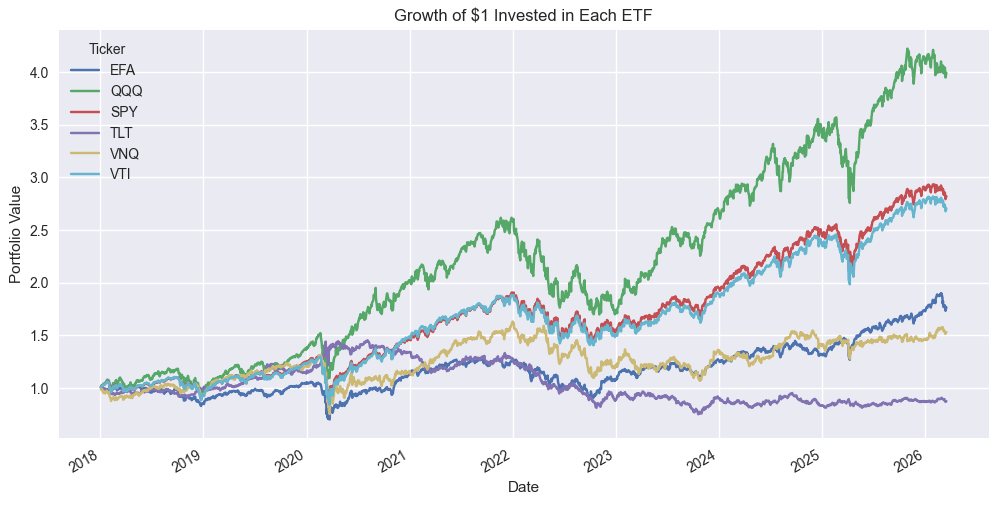

In [32]:
cumulative_returns = (1 + returns).cumprod()

cumulative_returns.plot(figsize=(12,6))
plt.title("Growth of $1 Invested in Each ETF")
plt.ylabel("Portfolio Value")
plt.xlabel("Date")

plt.savefig("../visualisations/growth_chart.png")

plt.show()


Step 5 — Annualized Returns

We calculate the annualized return of each ETF.  
This helps compare long-term performance across assets.

Assumption: 252 trading days per year.

In [12]:
annual_returns = returns.mean() * 252
annual_returns

Ticker
EFA    0.085639
QQQ    0.197966
SPY    0.145573
TLT   -0.004370
VNQ    0.076461
VTI    0.141164
dtype: float64

Step 6 — Volatility (Risk)

Volatility measures how much returns fluctuate over time.
Higher volatility indicates greater investment risk.

In [13]:
annual_volatility = returns.std() * np.sqrt(252)
annual_volatility

Ticker
EFA    0.179354
QQQ    0.238911
SPY    0.193140
TLT    0.156268
VNQ    0.220463
VTI    0.196935
dtype: float64

Step 7 — Risk vs Return

We compare each ETF's annual return with its volatility
to visualize the risk-return tradeoff.

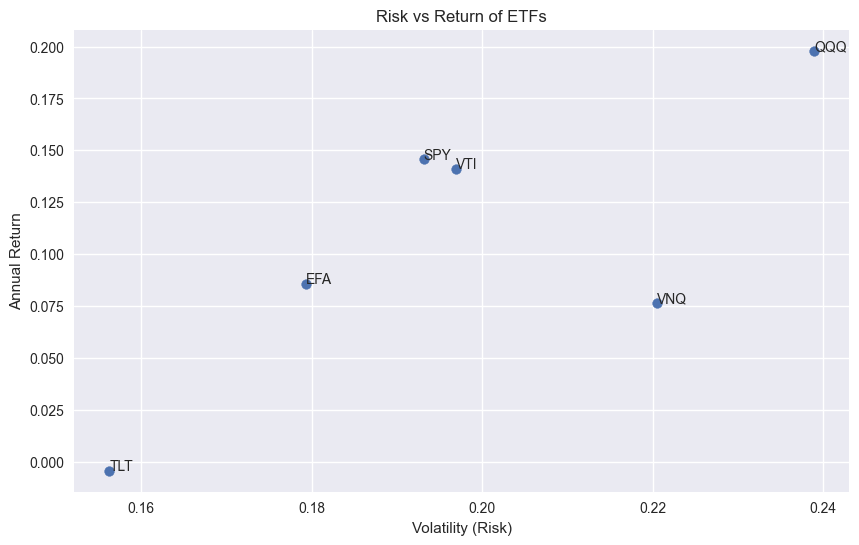

In [33]:
plt.figure(figsize=(10,6))

plt.scatter(annual_volatility, annual_returns)

for ticker in annual_returns.index:
    plt.annotate(ticker,
                 (annual_volatility[ticker], annual_returns[ticker]))

plt.xlabel("Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Risk vs Return of ETFs")
plt.savefig("../visualisations/risk_return_chart.png")
plt.show()


Step 8 — Correlation Matrix

Correlation measures how assets move relative to each other.
Diversification works best when correlations are low.

In [15]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,EFA,QQQ,SPY,TLT,VNQ,VTI
Ticker,,,,,,
EFA,1.000000,0.760093,0.853967,-0.107711,0.696433,0.859550
QQQ,0.760093,1.000000,0.937591,-0.100191,0.595622,0.932449
SPY,0.853967,0.937591,1.000000,-0.148733,0.742159,0.996095
TLT,-0.107711,-0.100191,-0.148733,1.000000,0.020305,-0.143001
VNQ,0.696433,0.595622,0.742159,0.020305,1.000000,0.754228
VTI,0.859550,0.932449,0.996095,-0.143001,0.754228,1.000000


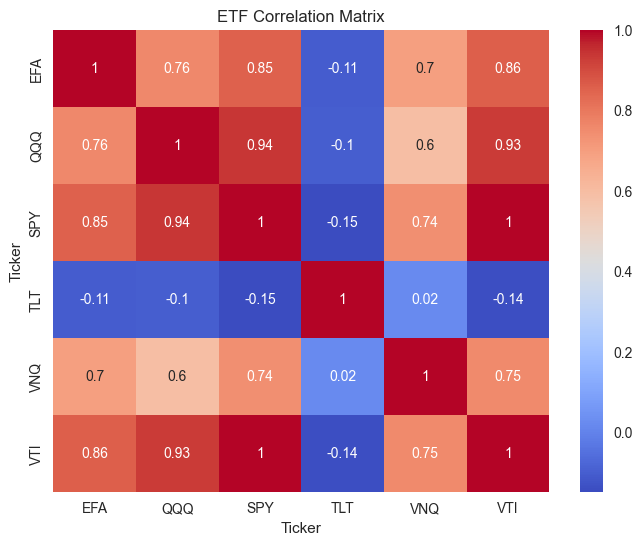

In [34]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("ETF Correlation Matrix")
plt.savefig("../visualisations/correlation_heatmap.png")
plt.show()


Step 10 — Portfolio Simulation

We simulate thousands of possible portfolios with different weight allocations
to identify the portfolio with the best risk-return tradeoff.

In [18]:
num_portfolios = 10000
num_assets = len(tickers)

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    
    weights_record.append(weights)

    portfolio_return = np.sum(weights * annual_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov()*252, weights)))
    
    sharpe_ratio = portfolio_return / portfolio_volatility

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = sharpe_ratio

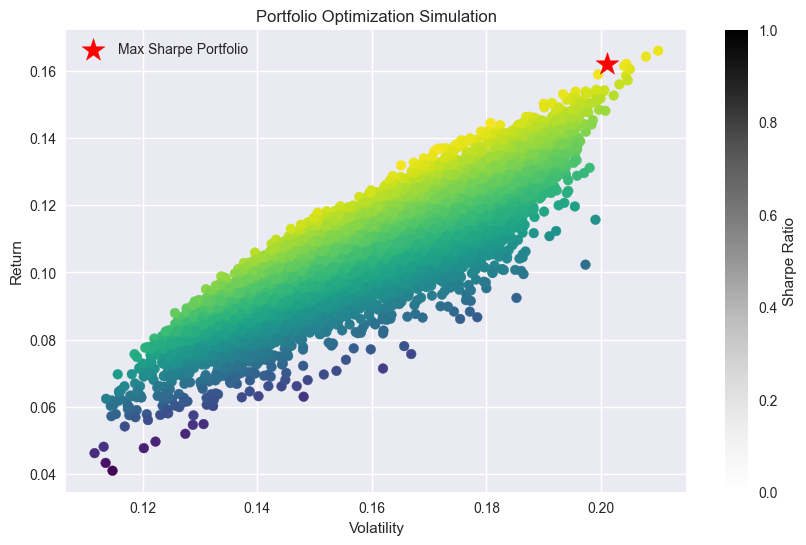

In [35]:
plt.figure(figsize=(10,6))

plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')

plt.scatter(results[1, max_sharpe_idx],
            results[0, max_sharpe_idx],
            color='red',
            marker='*',
            s=300,
            label='Max Sharpe Portfolio')

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Portfolio Optimization Simulation")

plt.legend()
plt.colorbar(label="Sharpe Ratio")
plt.savefig("../visualisations/portfolio_simulation.png")

plt.show()


Step 11 — Optimal Portfolio

We identify the portfolio with the highest Sharpe ratio from the simulation.

In [20]:
max_sharpe_idx = np.argmax(results[2])
optimal_weights = weights_record[max_sharpe_idx]

for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.2%}")

SPY: 1.18%
QQQ: 59.10%
VTI: 14.78%
EFA: 7.22%
VNQ: 3.44%
TLT: 14.28%


Step 12 — Optimal Portfolio Performance

We calculate the expected return, volatility, and Sharpe ratio
of the optimal portfolio.

In [22]:
print("Optimal Portfolio Performance\n")

print(f"Expected Annual Return: {results[0, max_sharpe_idx]:.2%}")
print(f"Expected Volatility: {results[1, max_sharpe_idx]:.2%}")
print(f"Sharpe Ratio: {results[2, max_sharpe_idx]:.2f}")

Optimal Portfolio Performance

Expected Annual Return: 16.20%
Expected Volatility: 20.10%
Sharpe Ratio: 0.81


Step 13 — Optimal Portfolio Allocation

In [23]:
weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": optimal_weights
})

weights_df["Weight"] = weights_df["Weight"].map("{:.2%}".format)

weights_df

,Asset,Weight
0,SPY,1.18%
1,QQQ,59.10%
2,VTI,14.78%
3,EFA,7.22%
4,VNQ,3.44%
5,TLT,14.28%


Step 14 — Portfolio Allocation Visualization

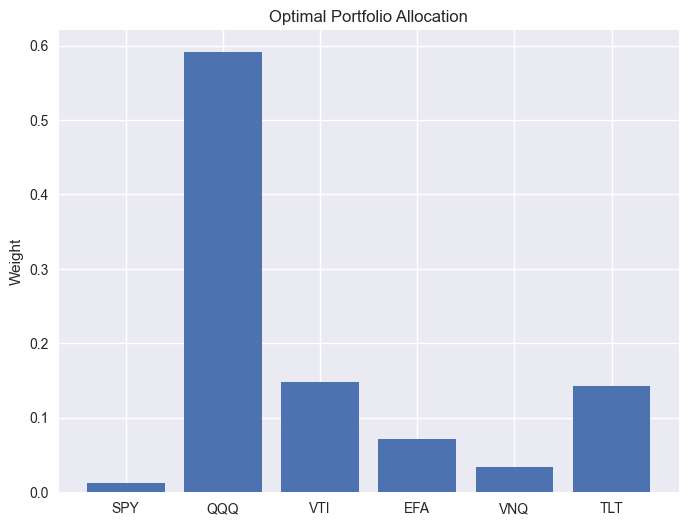

In [36]:
weights_df_plot = pd.DataFrame({
    "Asset": tickers,
    "Weight": optimal_weights
})

plt.figure(figsize=(8,6))
plt.bar(weights_df_plot["Asset"], weights_df_plot["Weight"])

plt.title("Optimal Portfolio Allocation")
plt.ylabel("Weight")
plt.savefig("../visualisations/allocation_chart.png")

plt.show()


Interpretation of Optimal Portfolio

The optimization suggests a portfolio heavily weighted toward QQQ,
which historically delivered the highest risk-adjusted returns in the
sample period (2018–present). Smaller allocations to bonds (TLT)
provide diversification benefits due to their low correlation with
equities.

However, the optimizer relies on historical returns and does not
incorporate constraints or forward-looking expectations, so the
results should be interpreted as a demonstration of portfolio
optimization rather than an investment recommendation.

In [26]:
data.to_csv("../data_csv/etf_prices.csv")
returns.to_csv("../data_csv/etf_returns.csv")